=== Path Check ===
  OK      S1Hand                     → /kaggle/input/datasets/smabrarrajin/sen1floods11-essentials/v1.2/data/flood_events/HandLabeled/S1Hand
  OK      LabelHand                  → /kaggle/input/datasets/smabrarrajin/sen1floods11-essentials/v1.2/data/flood_events/HandLabeled/LabelHand
  MISSING Weak S1 (unlabeled pool)   → None
  MISSING Weak label masks           → None

Deriving image-level labels from masks (flooded = water fraction ≥ 0.01) ...
  Chips: 441  (293 flooded | 148 non-flooded)

=== Training Sets (identical across all seeds) ===
  Supervised-only  : 176 chips  (121 flooded | 55 non-flooded)
  Full-supervision : 352 chips  (234 flooded | 118 non-flooded)
  Val              : 89 chips

Device  : cuda
GPU     : Tesla T4
Plan    : 2 baselines × 3 seeds × (1 dense@50ep + 10 pruned@50ep)
Levels  : [20, 40, 60, 80, 90]% | methods: ['unstructured', 'structured']

Dense VGG-16: 134.26M params | 30.93 GFLOPs


█████████████████████████████████████████████████████

100%|██████████| 528M/528M [00:04<00:00, 129MB/s]  


    dense s42 ep  1/50 │ loss  0.6589 │ acc 0.6742 │ f1 0.7387 │ auc 0.7842
    dense s42 ep  2/50 │ loss  0.6469 │ acc 0.7416 │ f1 0.7850 │ auc 0.8090
    dense s42 ep  3/50 │ loss  0.4727 │ acc 0.6517 │ f1 0.6593 │ auc 0.7508
    dense s42 ep  4/50 │ loss  0.4548 │ acc 0.5618 │ f1 0.5517 │ auc 0.7520
    dense s42 ep  5/50 │ loss  0.3410 │ acc 0.7528 │ f1 0.7885 │ auc 0.8229
    dense s42 ep  6/50 │ loss  0.2949 │ acc 0.7416 │ f1 0.7890 │ auc 0.8282
    dense s42 ep  7/50 │ loss  0.1778 │ acc 0.7640 │ f1 0.8142 │ auc 0.8150
    dense s42 ep  8/50 │ loss  0.1573 │ acc 0.7753 │ f1 0.8438 │ auc 0.8198
    dense s42 ep  9/50 │ loss  0.1264 │ acc 0.7640 │ f1 0.8293 │ auc 0.8107
    dense s42 ep 10/50 │ loss  0.0304 │ acc 0.7079 │ f1 0.7636 │ auc 0.7554
    dense s42 ep 11/50 │ loss  0.0111 │ acc 0.7416 │ f1 0.8099 │ auc 0.8209
    dense s42 ep 12/50 │ loss  0.0373 │ acc 0.7865 │ f1 0.8403 │ auc 0.8243
    dense s42 ep 13/50 │ loss  0.0251 │ acc 0.7753 │ f1 0.8333 │ auc 0.8260
    dense s4

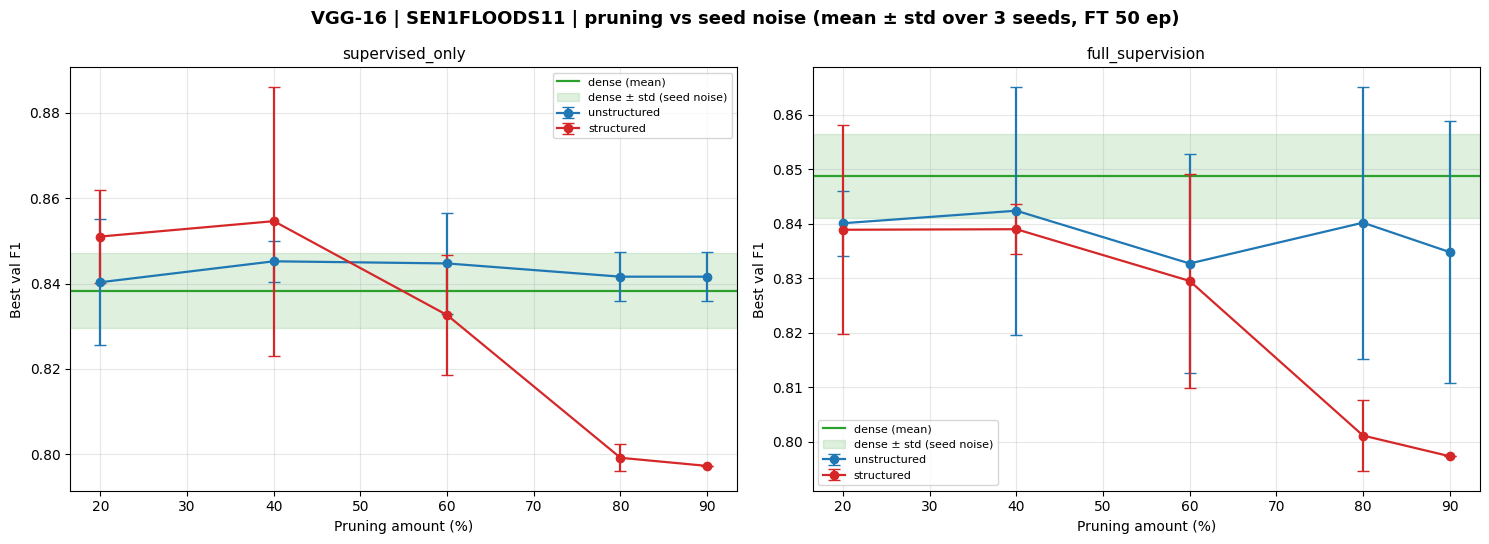

Saved → vgg16_sen1floods11_pruning50_vs_noise.png

✓ All done.


In [2]:
import os, copy, random, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
from pathlib import Path
import rasterio
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.nn.utils.prune as prune
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from torchvision.models import VGG16_Weights
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
)
import matplotlib.pyplot as plt

# ── 0. Experiment knobs ────────────────────────────────────────────────
DATA_SEED  = 42                    # fixed → identical splits in every run
RUN_SEEDS  = [42, 123, 2024]       # vary ONLY training randomness
LEVELS     = [0.20, 0.40, 0.60, 0.80, 0.90]   # 20 → 90, steps of 20
METHODS    = ["unstructured", "structured"]
FT_EPOCHS  = 50                    # fine-tune budget = dense budget
E          = 50                    # dense training epochs

random.seed(DATA_SEED); np.random.seed(DATA_SEED)
torch.manual_seed(DATA_SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(DATA_SEED)

# ── 1. PATHS — auto-detect the dataset layout ──────────────────────────
ROOT = Path("/kaggle/input/sen1floods11-essentials")
if not ROOT.exists():
    import kagglehub
    ROOT = Path(kagglehub.dataset_download("smabrarrajin/sen1floods11-essentials"))

def find_dir(root, target_name):
    """Walk directories only (cheap) and return the first match by name."""
    for dirpath, dirnames, _ in os.walk(root):
        for d in dirnames:
            if d.lower() == target_name.lower():
                return Path(dirpath) / d
    return None

S1_DIR        = find_dir(ROOT, "S1Hand")
LABEL_DIR     = find_dir(ROOT, "LabelHand")
WEAK_DIR      = find_dir(ROOT, "S1Weak")            # weakly-labeled S1 chips
WEAK_LBL_DIR  = (find_dir(ROOT, "S1OtsuLabelWeak")  # weak reference masks
                 or find_dir(ROOT, "S2IndexLabelWeak"))

print("=== Path Check ===")
for name, p in [("S1Hand", S1_DIR), ("LabelHand", LABEL_DIR),
                ("Weak S1 (unlabeled pool)", WEAK_DIR),
                ("Weak label masks", WEAK_LBL_DIR)]:
    print(f"  {'OK' if p else 'MISSING':7} {name:<26} → {p}")
assert S1_DIR is not None and LABEL_DIR is not None, \
    "Could not locate S1Hand / LabelHand folders — check dataset root."

# ── 2. Derive image-level labels from pixel masks ──────────────────────
#  (identical constants and RNG call order, seeded with DATA_SEED=42
#   → chip-for-chip identical splits to every previous script)
FLOOD_THRESHOLD    = 0.01   # chip = flooded if ≥1% of valid pixels are water
UNLABELED_FRACTION = 0.50   # fallback only (when no weak S1 folder exists)
MAX_UNLABELED      = 1500   # cap unlabeled pool (RAM guard)

def water_fraction(mask_path):
    """Fraction of VALID pixels (mask != -1) that are water (mask == 1)."""
    with rasterio.open(mask_path) as src:
        m = src.read(1)
    valid = m != -1
    if not valid.any():
        return None
    return float((m[valid] == 1).mean())

print("\nDeriving image-level labels from masks "
      f"(flooded = water fraction ≥ {FLOOD_THRESHOLD:.2f}) ...")

all_samples = []                      # (s1_path, label)
for mask_path in sorted(LABEL_DIR.glob("*.tif")):
    stem    = mask_path.name.replace("_LabelHand.tif", "")
    s1_path = S1_DIR / f"{stem}_S1Hand.tif"
    if not s1_path.exists():
        continue
    wf = water_fraction(mask_path)
    if wf is None:                    # chip is entirely no-data
        continue
    all_samples.append((str(s1_path), int(wf >= FLOOD_THRESHOLD)))

flooded_s    = [s for s in all_samples if s[1] == 1]
nonflooded_s = [s for s in all_samples if s[1] == 0]
print(f"  Chips: {len(all_samples)}  "
      f"({len(flooded_s)} flooded | {len(nonflooded_s)} non-flooded)")

# ── 3. 80/20 labeled split (same RNG order as before) ──────────────────
random.shuffle(flooded_s)
random.shuffle(nonflooded_s)

def split80(lst):
    cut = int(0.8 * len(lst))
    return lst[:cut], lst[cut:]

f_train,  f_val  = split80(flooded_s)
nf_train, nf_val = split80(nonflooded_s)

TRAIN_SAMPLES = f_train + nf_train
VAL_SAMPLES   = f_val   + nf_val

# ── 4. Unlabeled pool (same RNG order as before) ───────────────────────
if WEAK_DIR is not None:
    UNLABELED_PATHS = [str(p) for p in sorted(WEAK_DIR.glob("*.tif"))]
    random.shuffle(UNLABELED_PATHS)
    UNLABELED_PATHS = UNLABELED_PATHS[:MAX_UNLABELED]
else:
    random.shuffle(TRAIN_SAMPLES)
    cut             = int((1 - UNLABELED_FRACTION) * len(TRAIN_SAMPLES))
    UNLABELED_PATHS = [p for p, _ in TRAIN_SAMPLES[cut:]]
    HIDDEN_TRUE     = {p: l for p, l in TRAIN_SAMPLES[cut:]}
    TRAIN_SAMPLES   = TRAIN_SAMPLES[:cut]

UNLABELED_TRUE = {}
if WEAK_DIR is None:
    UNLABELED_TRUE = HIDDEN_TRUE
elif WEAK_LBL_DIR is not None:
    weak_suffix = f"_{WEAK_LBL_DIR.name}.tif"
    s1w_suffix  = f"_{WEAK_DIR.name}.tif"
    for p in UNLABELED_PATHS:
        stem = Path(p).name.replace(s1w_suffix, "")
        wm   = WEAK_LBL_DIR / f"{stem}{weak_suffix}"
        if not wm.exists():
            continue
        wf = water_fraction(wm)
        if wf is not None:
            UNLABELED_TRUE[p] = int(wf >= FLOOD_THRESHOLD)

# ── 5. The two baseline training sets ──────────────────────────────────
SUPERVISED_ONLY_SET  = list(TRAIN_SAMPLES)
FULL_SUPERVISION_SET = list(TRAIN_SAMPLES) + \
    [(p, UNLABELED_TRUE[p]) for p in UNLABELED_PATHS if p in UNLABELED_TRUE]

#  Edit this list to split the workload across Kaggle sessions:
BASELINE_RUNS = [("supervised_only",  SUPERVISED_ONLY_SET),
                 ("full_supervision", FULL_SUPERVISION_SET)]

def class_counts(samples):
    f  = sum(1 for _, l in samples if l == 1)
    nf = sum(1 for _, l in samples if l == 0)
    return f, nf

print(f"\n=== Training Sets (identical across all seeds) ===")
for name, s in [("Supervised-only", SUPERVISED_ONLY_SET),
                ("Full-supervision", FULL_SUPERVISION_SET)]:
    f, nf = class_counts(s)
    print(f"  {name:<17}: {len(s)} chips  ({f} flooded | {nf} non-flooded)")
print(f"  Val              : {len(VAL_SAMPLES)} chips")

# ── 6. Hyper-parameters ────────────────────────────────────────────────
IMG_SIZE  = 224
BATCH     = 16
LR        = 1e-4
DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")

n_cfg = len(METHODS) * len(LEVELS)
print(f"\nDevice  : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
print(f"Plan    : {len(BASELINE_RUNS)} baselines × {len(RUN_SEEDS)} seeds "
      f"× (1 dense@{E}ep + {n_cfg} pruned@{FT_EPOCHS}ep)")
print(f"Levels  : {[int(a*100) for a in LEVELS]}% | methods: {METHODS}")

# ── 7. SAR chip loading → 3-channel tensor (identical) ─────────────────
DB_MIN, DB_MAX = -50.0, 1.0
IMAGENET_MEAN  = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD   = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def load_s1_tensor(path):
    """2-band SAR GeoTIFF → normalized 3×224×224 float tensor."""
    with rasterio.open(path) as src:
        arr = src.read().astype(np.float32)
    arr = np.nan_to_num(arr, nan=DB_MIN)
    arr = np.clip(arr, DB_MIN, DB_MAX)
    arr = (arr - DB_MIN) / (DB_MAX - DB_MIN)
    vv, vh = arr[0], arr[1]
    img = np.stack([vv, vh, (vv + vh) / 2.0])
    t = torch.from_numpy(img)
    t = F.interpolate(t.unsqueeze(0), size=(IMG_SIZE, IMG_SIZE),
                      mode="bilinear", align_corners=False).squeeze(0)
    return (t - IMAGENET_MEAN) / IMAGENET_STD

class LabeledDS(Dataset):
    def __init__(self, samples):
        self.samples = samples
    def __len__(self): return len(self.samples)
    def __getitem__(self, i):
        path, lbl = self.samples[i]
        return load_s1_tensor(path), torch.tensor(lbl, dtype=torch.float32)

val_ldr = DataLoader(LabeledDS(VAL_SAMPLES), batch_size=BATCH,
                     shuffle=False, num_workers=2, pin_memory=True)

def make_train_loader(samples):
    f, nf = class_counts(samples)
    n     = len(samples)
    cw    = [n/(2*nf), n/(2*f)]
    sw    = [cw[int(l)] for _, l in samples]
    sampler = WeightedRandomSampler(sw, len(sw), replacement=True)
    return DataLoader(LabeledDS(samples), batch_size=BATCH, sampler=sampler,
                      num_workers=2, pin_memory=True)

# ── 8. Model builder ───────────────────────────────────────────────────
def build_vgg16(pretrained=True):
    w = VGG16_Weights.IMAGENET1K_V1 if pretrained else None
    m = models.vgg16(weights=w)
    m.classifier[-1] = nn.Linear(4096, 1)   # 4096 → 1
    return m

# ── 9. Params & FLOPs profiler (hook-based, no dependencies) ───────────
def profile_model(model, img_size=224):
    """Count parameters and MACs/FLOPs for one forward pass (batch=1)."""
    model = model.to("cpu").eval()
    macs_total = {"v": 0}
    per_layer  = {}
    hooks = []

    def conv_hook(name):
        def fn(mod, inp, out):
            k = mod.kernel_size[0] * mod.kernel_size[1]
            macs = out.numel() * (mod.in_channels // mod.groups) * k
            macs_total["v"] += macs
            per_layer[name] = macs
        return fn

    def lin_hook(name):
        def fn(mod, inp, out):
            macs = mod.in_features * mod.out_features
            macs_total["v"] += macs
            per_layer[name] = macs
        return fn

    for name, mod in model.named_modules():
        if isinstance(mod, nn.Conv2d):
            hooks.append(mod.register_forward_hook(conv_hook(name)))
        elif isinstance(mod, nn.Linear):
            hooks.append(mod.register_forward_hook(lin_hook(name)))

    with torch.no_grad():
        model(torch.randn(1, 3, img_size, img_size))
    for h in hooks: h.remove()

    n_params = sum(p.numel() for p in model.parameters())
    return n_params, macs_total["v"], per_layer

def count_nonzero_params(model):
    total, nonzero = 0, 0
    for p in model.parameters():
        total   += p.numel()
        nonzero += int((p != 0).sum().item())
    return total, nonzero

def effective_macs(model, per_layer_macs):
    """Theoretical MACs of surviving (nonzero) weights."""
    eff = 0
    named = dict(model.named_modules())
    for lname, macs in per_layer_macs.items():
        mod = named.get(lname)
        if mod is None:
            eff += macs; continue
        w = mod.weight.detach()
        frac = float((w != 0).sum().item()) / max(w.numel(), 1)
        eff += macs * frac
    return eff

# ── 10. Evaluation ─────────────────────────────────────────────────────
def evaluate(model, loader):
    model.eval()
    probs_all, preds_all, lbls_all = [], [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            logits = model(imgs.to(DEVICE)).squeeze(1)
            probs  = torch.sigmoid(logits).cpu().numpy()
            preds  = (probs >= 0.5).astype(int)
            probs_all.extend(probs)
            preds_all.extend(preds)
            lbls_all.extend(lbls.numpy().astype(int))
    acc  = accuracy_score(lbls_all, preds_all)
    f1   = f1_score(lbls_all,       preds_all, zero_division=0)
    prec = precision_score(lbls_all, preds_all, zero_division=0)
    rec  = recall_score(lbls_all,   preds_all, zero_division=0)
    try:    roc = roc_auc_score(lbls_all, probs_all)
    except: roc = float("nan")
    return acc, f1, prec, rec, roc

# ── 11. Training / fine-tuning loop (keeps best-F1 checkpoint) ─────────
def train_loop(model, samples, epochs, tag=""):
    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.BCEWithLogitsLoss()
    train_ldr = make_train_loader(samples)

    best_f1, best_epoch = -1, -1
    best_state, best_metrics = None, None
    for ep in range(epochs):
        model.train()
        total_loss, n_batches = 0.0, 0
        for imgs, lbls in train_ldr:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(imgs).squeeze(1), lbls)
            loss.backward(); optimizer.step()
            total_loss += loss.item(); n_batches += 1
        acc, f1, prec, rec, roc = evaluate(model, val_ldr)
        print(f"    {tag} ep {ep+1:2d}/{epochs} │ "
              f"loss {total_loss/max(n_batches,1):7.4f} │ acc {acc:.4f} │ "
              f"f1 {f1:.4f} │ auc {roc:.4f}")
        if f1 > best_f1:
            best_f1      = f1
            best_epoch   = ep + 1
            best_metrics = (acc, f1, prec, rec, roc)
            best_state   = copy.deepcopy(model.state_dict())
    model.load_state_dict(best_state)      # keep the best checkpoint
    return best_metrics, best_epoch

# ── 12. Pruning utilities ──────────────────────────────────────────────
def prunable_modules(model):
    mods = []
    for name, mod in model.named_modules():
        if isinstance(mod, (nn.Conv2d, nn.Linear)):
            mods.append((name, mod))
    return mods

def apply_unstructured(model, amount):
    params = [(m, "weight") for _, m in prunable_modules(model)]
    prune.global_unstructured(params, pruning_method=prune.L1Unstructured,
                              amount=amount)

def apply_structured(model, amount):
    """L1 structured pruning: conv output filters + hidden-FC neurons
    (VGG-specific — the two 4096-wide FCs hold ~90% of the params).
    The final 1-node output layer is left intact."""
    for name, mod in model.named_modules():
        if isinstance(mod, nn.Conv2d) and mod.out_channels > 8:
            prune.ln_structured(mod, "weight", amount=amount, n=1, dim=0)
        elif isinstance(mod, nn.Linear) and mod.out_features > 8:
            prune.ln_structured(mod, "weight", amount=amount, n=1, dim=0)

def finalize_pruning(model):
    for _, mod in prunable_modules(model):
        if prune.is_pruned(mod):
            try: prune.remove(mod, "weight")
            except ValueError: pass

# ── 13. Per-seed dense checkpoint (train or reuse) ─────────────────────
OUT = "/kaggle/working" if os.path.isdir("/kaggle/working") else "."

def find_weights(fname):
    """Look for previously trained weights in Kaggle inputs / cwd."""
    for base in ["/kaggle/input", "."]:
        if not os.path.isdir(base):
            continue
        for dirpath, _, filenames in os.walk(base):
            if fname in filenames:
                return os.path.join(dirpath, fname)
    return None

def get_dense(run_name, samples, seed):
    """Dense VGG-16 for (run, seed): load per-seed checkpoint if it was
    attached as input (from a previous session), else train E epochs."""
    fname = f"vgg16_dense_{run_name}_seed{seed}.pth"
    path  = find_weights(fname)

    torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

    if path is not None:
        print(f"\n  Reusing dense checkpoint ← {path}")
        model = build_vgg16(pretrained=False).to(DEVICE)
        model.load_state_dict(torch.load(path, map_location=DEVICE))
        metrics = evaluate(model, val_ldr)
        best_ep = -1     # unknown (from previous session)
    else:
        print(f"\n  Training dense | {run_name} | seed {seed} "
              f"| {E} epochs ...")
        model = build_vgg16(pretrained=True).to(DEVICE)
        metrics, best_ep = train_loop(model, samples, E,
                                      tag=f"dense s{seed}")
        torch.save(model.state_dict(), f"{OUT}/{fname}")
        print(f"  Saved dense checkpoint → {fname}")
    return model, metrics, best_ep

# ── 14. THE MULTI-SEED PRUNING STUDY ───────────────────────────────────
# dense reference profile (identical architecture for every run)
_ref = build_vgg16(pretrained=False)
DENSE_PARAMS, DENSE_MACS, PER_LAYER_MACS = profile_model(_ref)
del _ref
print(f"\nDense VGG-16: {DENSE_PARAMS/1e6:.2f}M params | "
      f"{2*DENSE_MACS/1e9:.2f} GFLOPs")

CONFIGS = [(m, a) for m in METHODS for a in LEVELS]
study_rows = []

for run_name, samples in BASELINE_RUNS:
    for seed in RUN_SEEDS:
        print("\n\n" + "█"*88)
        print(f"  VGG-16 PRUNING  |  {run_name}  |  seed {seed}")
        print("█"*88)

        dense_model, dmetrics, dep = get_dense(run_name, samples, seed)
        acc, f1, prec, rec, roc = dmetrics
        study_rows.append(dict(
            run=run_name, seed=seed, method="dense", amount=0.0,
            best_epoch=dep, params_nonzero=DENSE_PARAMS,
            macs_effective=DENSE_MACS,
            accuracy=round(acc,4), f1=round(f1,4),
            precision=round(prec,4), recall=round(rec,4),
            roc_auc=round(roc,4)))
        print(f"  DENSE │ seed {seed} │ F1 {f1:.4f} │ AUC {roc:.4f}")

        dense_state = copy.deepcopy(dense_model.state_dict())
        del dense_model
        if DEVICE.type == "cuda": torch.cuda.empty_cache()

        for method, amount in CONFIGS:
            print(f"\n  ── {run_name} │ seed {seed} │ {method} @ "
                  f"{amount:.0%} │ FT {FT_EPOCHS} ep ──")
            # re-seed so FT randomness is reproducible per (config, seed)
            torch.manual_seed(seed)
            if torch.cuda.is_available():
                torch.cuda.manual_seed_all(seed)

            model = build_vgg16(pretrained=False).to(DEVICE)
            model.load_state_dict(dense_state)

            if method == "unstructured":
                apply_unstructured(model, amount)
            else:
                apply_structured(model, amount)

            ft_metrics, ft_ep = train_loop(
                model, samples, FT_EPOCHS,
                tag=f"{method[:6]}@{amount:.0%} s{seed}")
            finalize_pruning(model)

            total, nonzero = count_nonzero_params(model)
            eff = effective_macs(model, PER_LAYER_MACS)
            acc, f1, prec, rec, roc = ft_metrics

            study_rows.append(dict(
                run=run_name, seed=seed, method=method, amount=amount,
                best_epoch=ft_ep, params_nonzero=nonzero,
                macs_effective=int(eff),
                accuracy=round(acc,4), f1=round(f1,4),
                precision=round(prec,4), recall=round(rec,4),
                roc_auc=round(roc,4)))

            print(f"    → NZ params {nonzero/1e6:.2f}M │ "
                  f"eff FLOPs {2*eff/1e9:.2f}G │ F1 {f1:.4f} "
                  f"(best ep {ft_ep})")

            del model
            if DEVICE.type == "cuda": torch.cuda.empty_cache()

        # incremental save after each (run, seed) block — crash-safe
        pd.DataFrame(study_rows).to_csv(
            f"{OUT}/vgg16_sen1floods11_pruning50_perseed.csv", index=False)
        print(f"\n  [checkpoint] results so far saved → "
              f"vgg16_sen1floods11_pruning50_perseed.csv")

# ── 15. Aggregate: mean ± std across seeds per config ──────────────────
study_df = pd.DataFrame(study_rows)

agg_rows = []
for run_name, _ in BASELINE_RUNS:
    for method in ["dense"] + METHODS:
        amounts = [0.0] if method == "dense" else LEVELS
        for amount in amounts:
            sub = study_df[(study_df["run"] == run_name) &
                           (study_df["method"] == method) &
                           (study_df["amount"] == amount)]
            if len(sub) == 0:
                continue
            agg_rows.append(dict(
                run=run_name, method=method, amount=amount,
                n_seeds=len(sub),
                f1_mean=round(sub["f1"].mean(), 4),
                f1_std=round(sub["f1"].std() if len(sub) > 1 else 0.0, 4),
                f1_min=round(sub["f1"].min(), 4),
                f1_max=round(sub["f1"].max(), 4),
                acc_mean=round(sub["accuracy"].mean(), 4),
                auc_mean=round(sub["roc_auc"].mean(), 4),
                params_nonzero=int(sub["params_nonzero"].mean()),
                macs_effective=int(sub["macs_effective"].mean())))
agg_df = pd.DataFrame(agg_rows)

print("\n\n" + "═"*104)
print("  MULTI-SEED PRUNING SUMMARY — VGG-16 | SEN1FLOODS11 | "
      f"mean ± std over {len(RUN_SEEDS)} seeds | FT {FT_EPOCHS} ep")
print("═"*104)
print(f"{'Run':<18} │ {'Method':<13} │ {'Amt':>4} │ {'NZ params':>10} │ "
      f"{'F1 mean':>8} │ {'F1 std':>7} │ {'F1 min':>7} │ {'F1 max':>7} │ "
      f"{'AUC':>6}")
print("─"*104)
for _, r in agg_df.iterrows():
    print(f"{r['run']:<18} │ {r['method']:<13} │ {r['amount']:>4.0%} │ "
          f"{r['params_nonzero']/1e6:>8.2f} M │ {r['f1_mean']:>8.4f} │ "
          f"{r['f1_std']:>7.4f} │ {r['f1_min']:>7.4f} │ "
          f"{r['f1_max']:>7.4f} │ {r['auc_mean']:>6.4f}")
print("═"*104)

# significance read-out: pruned vs dense, in units of seed noise
print("\n  Δ vs dense (same run), compared against seed noise:")
for run_name, _ in BASELINE_RUNS:
    d = agg_df[(agg_df["run"] == run_name) &
               (agg_df["method"] == "dense")]
    if len(d) == 0: continue
    d_mean, d_std = d.iloc[0]["f1_mean"], d.iloc[0]["f1_std"]
    for _, r in agg_df[(agg_df["run"] == run_name) &
                       (agg_df["method"] != "dense")].iterrows():
        delta = r["f1_mean"] - d_mean
        noise = max(d_std, r["f1_std"], 1e-9)
        verdict = "REAL?" if abs(delta) > 2*noise else "noise"
        print(f"    {run_name:<18} {r['method']:<13} "
              f"@{r['amount']:>4.0%}  ΔF1 = {delta:+.4f}  "
              f"(max std {noise:.4f}) → {verdict}")

# ── 16. Save ───────────────────────────────────────────────────────────
study_df.to_csv(f"{OUT}/vgg16_sen1floods11_pruning50_perseed.csv",
                index=False)
agg_df.to_csv(f"{OUT}/vgg16_sen1floods11_pruning50_aggregate.csv",
              index=False)
print(f"\nSaved → vgg16_sen1floods11_pruning50_perseed.csv")
print(f"Saved → vgg16_sen1floods11_pruning50_aggregate.csv")

# ── 17. Plot — F1 vs pruning level with seed error bars ────────────────
fig, axes = plt.subplots(1, len(BASELINE_RUNS), figsize=(15, 5.5),
                         squeeze=False)
fig.suptitle(f"VGG-16 | SEN1FLOODS11 | pruning vs seed noise "
             f"(mean ± std over {len(RUN_SEEDS)} seeds, "
             f"FT {FT_EPOCHS} ep)", fontsize=13, fontweight="bold")
mcolors = {"unstructured": "tab:blue", "structured": "tab:red"}

for ax, (run_name, _) in zip(axes.flat, BASELINE_RUNS):
    d = agg_df[(agg_df["run"] == run_name) &
               (agg_df["method"] == "dense")]
    if len(d) > 0:
        dm, ds = d.iloc[0]["f1_mean"], d.iloc[0]["f1_std"]
        ax.axhline(dm, color="tab:green", linewidth=1.6,
                   label="dense (mean)")
        ax.axhspan(dm - ds, dm + ds, color="tab:green", alpha=0.15,
                   label="dense ± std (seed noise)")
    for method in METHODS:
        sub = agg_df[(agg_df["run"] == run_name) &
                     (agg_df["method"] == method)].sort_values("amount")
        ax.errorbar([a*100 for a in sub["amount"]], sub["f1_mean"],
                    yerr=sub["f1_std"], color=mcolors[method],
                    marker="o", capsize=4, linewidth=1.6, label=method)
    ax.set_title(run_name, fontsize=11)
    ax.set_xlabel("Pruning amount (%)")
    ax.set_ylabel("Best val F1")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{OUT}/vgg16_sen1floods11_pruning50_vs_noise.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved → vgg16_sen1floods11_pruning50_vs_noise.png")

print("\n✓ All done.")
